In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [30]:
PROJECT_ROOT = Path("..")

TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"
TEST_PATH = PROJECT_ROOT / "data" / "raw" / "test.csv"
TRUTH_PATH = PROJECT_ROOT / "data" / "raw" / "truth.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
truth_df = pd.read_csv(TRUTH_PATH)

train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])

print("Train :", train_df.shape)
print("Test  :", test_df.shape)
print("Truth :", truth_df.shape)

Train : (5142, 13)
Test  : (1575, 11)
Truth : (1575, 2)


In [31]:
print("=" * 60)
print("TRAINING DATA INFORMATION")
print("=" * 60)

train_df.info()

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(train_df.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATES")
print("=" * 60)

print("Duplicate rows:", train_df.duplicated().sum())
print(
    "Duplicate date-store combinations:",
    train_df.duplicated(subset=["date", "store"]).sum()
)

print("\n" + "=" * 60)
print("DATE RANGE")
print("=" * 60)

print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Test :", test_df["date"].min(), "to", test_df["date"].max())

print("\nNumber of stores:", train_df["store"].nunique())
print("Stores:", sorted(train_df["store"].unique()))

TRAINING DATA INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 5142 entries, 0 to 5141
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               5142 non-null   datetime64[us]
 1   store              5142 non-null   str           
 2   is_state_holiday   5142 non-null   str           
 3   is_school_holiday  5142 non-null   str           
 4   is_special_day     5142 non-null   str           
 5   temperature_max    5142 non-null   float64       
 6   temperature_min    5142 non-null   float64       
 7   temperature_mean   5142 non-null   float64       
 8   sunshine_sum       5142 non-null   int64         
 9   precipitation_sum  5142 non-null   float64       
 10  sales              5142 non-null   float64       
 11  unsold             3226 non-null   float64       
 12  ordered            3226 non-null   float64       
dtypes: datetime64[us](1), float64(7), int64(1), str(

In [32]:
print("=" * 60)
print("TARGET STATISTICS")
print("=" * 60)

print(train_df["sales"].describe())

print("\n" + "=" * 60)
print("CATEGORICAL VARIABLES")
print("=" * 60)

for col in [
    "store",
    "is_state_holiday",
    "is_school_holiday",
    "is_special_day"
]:
    print(f"\n{col}:")
    print(train_df[col].value_counts(dropna=False))

TARGET STATISTICS
count    5142.000000
mean        0.115530
std         0.997744
min        -1.656999
25%        -0.582000
50%         0.045276
75%         0.712195
max         7.539953
Name: sales, dtype: float64

CATEGORICAL VARIABLES

store:
store
store_5    847
store_8    847
store_7    847
store_4    847
store_1    847
store_6    331
store_0    273
store_3    242
store_2     61
Name: count, dtype: int64

is_state_holiday:
is_state_holiday
normal_day       5025
state_holiday     114
day_after           2
day_before          1
Name: count, dtype: int64

is_school_holiday:
is_school_holiday
normal_day        3957
school_holiday    1185
Name: count, dtype: int64

is_special_day:
is_special_day
normal_day     4947
special_day     192
day_before        3
Name: count, dtype: int64


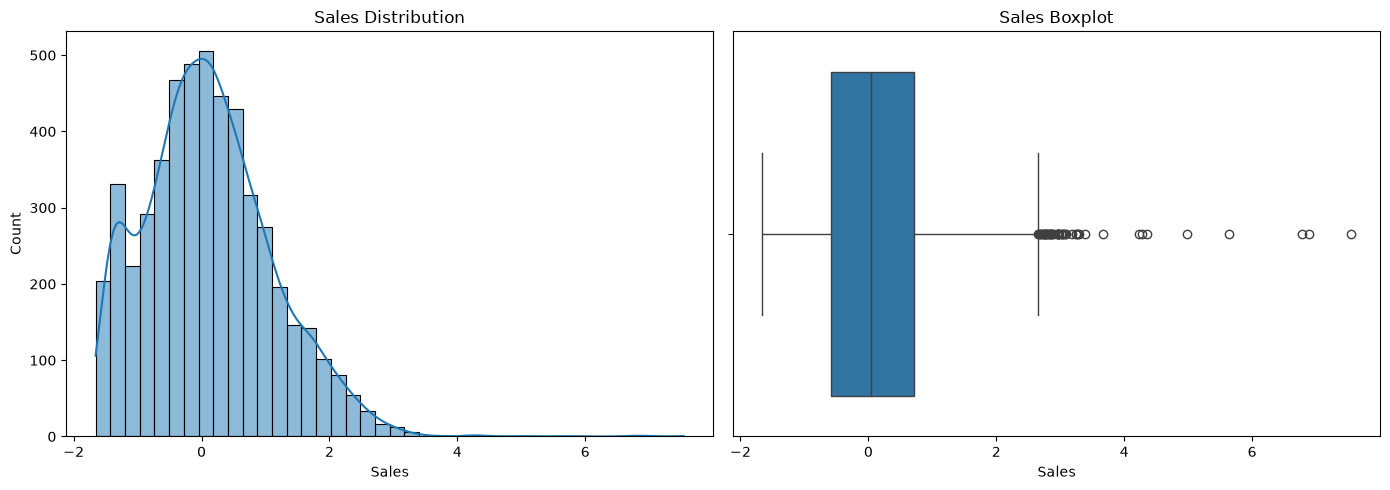

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    train_df["sales"],
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales")

sns.boxplot(
    x=train_df["sales"],
    ax=axes[1]
)

axes[1].set_title("Sales Boxplot")
axes[1].set_xlabel("Sales")

plt.tight_layout()
plt.show()

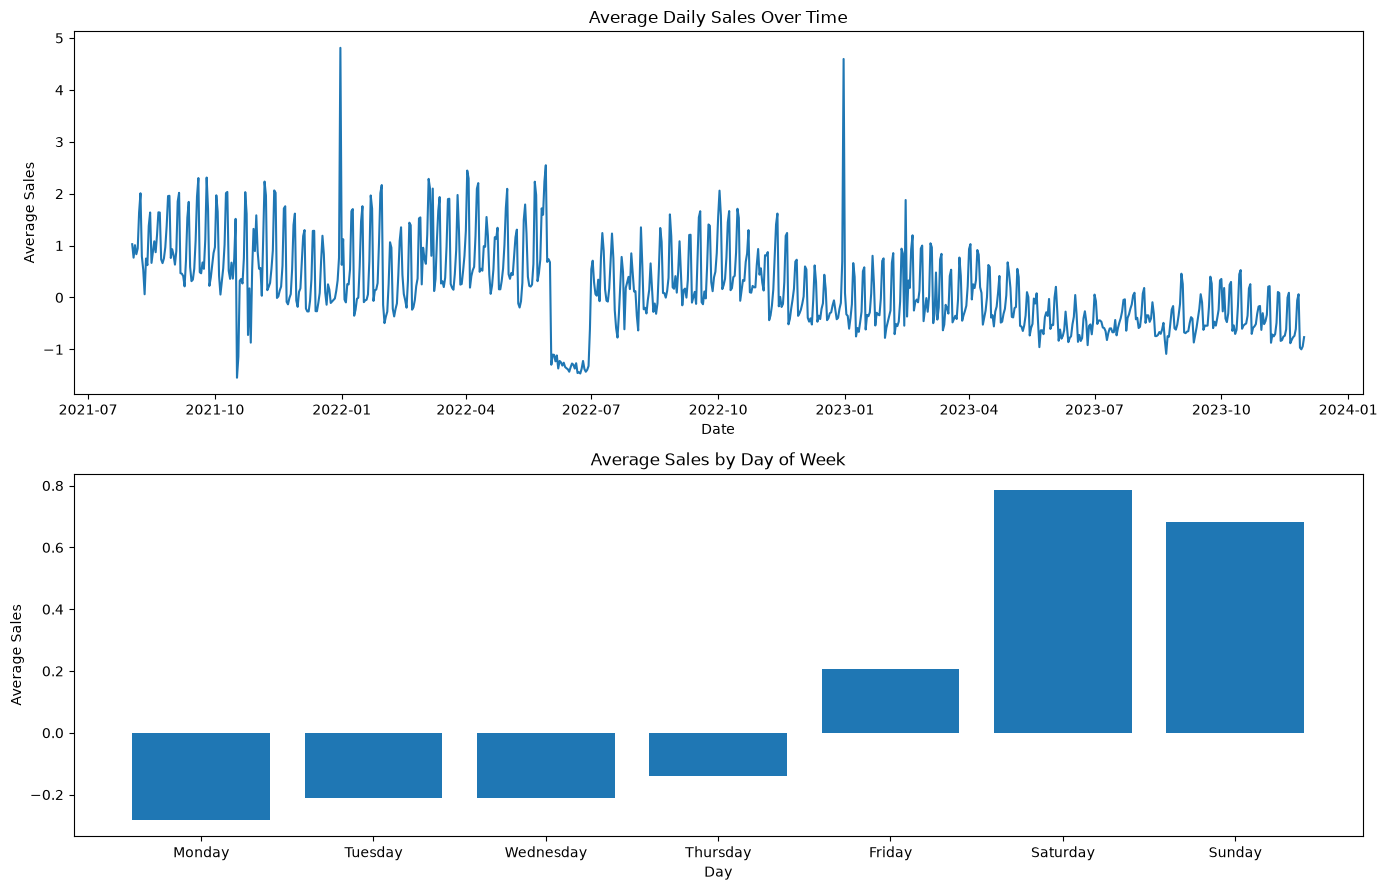

In [34]:
daily_sales = (
    train_df
    .groupby("date")["sales"]
    .mean()
    .reset_index()
)

train_df["day_of_week"] = train_df["date"].dt.dayofweek

weekday_sales = (
    train_df
    .groupby("day_of_week")["sales"]
    .mean()
)

weekday_names = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(
    daily_sales["date"],
    daily_sales["sales"]
)

axes[0].set_title("Average Daily Sales Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Average Sales")

axes[1].bar(
    [weekday_names[i] for i in weekday_sales.index],
    weekday_sales.values
)

axes[1].set_title("Average Sales by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Average Sales")

plt.tight_layout()
plt.show()

           mean  median     std  count
store                                 
store_0 -1.3645 -1.4052  0.1629    273
store_1 -0.0329 -0.2112  0.8123    847
store_2 -0.8463 -0.9248  0.2846     61
store_3 -0.7002 -0.7534  0.3516    242
store_4  0.1884  0.0313  0.8451    847
store_5  0.1696  0.0756  0.7242    847
store_6 -1.0395 -1.1417  0.3882    331
store_7  0.7872  0.7309  0.8900    847
store_8  0.6961  0.5000  0.9721    847


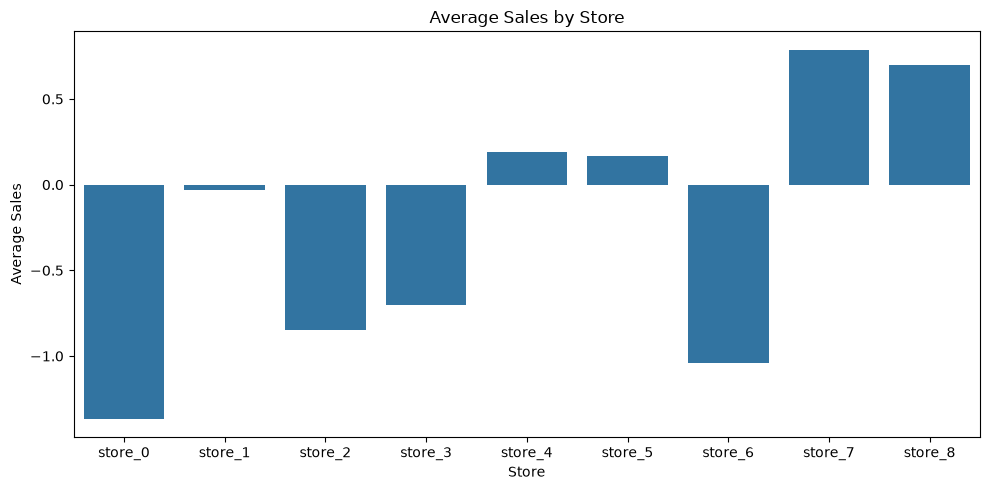

In [35]:
store_summary = (
    train_df
    .groupby("store")["sales"]
    .agg(["mean", "median", "std", "count"])
    .round(4)
)

print(store_summary)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=store_summary.reset_index(),
    x="store",
    y="mean"
)

plt.title("Average Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

In [36]:
numeric_cols = [
    "temperature_max",
    "temperature_min",
    "temperature_mean",
    "sunshine_sum",
    "precipitation_sum",
    "sales"
]

print("Correlation with sales:")
print(
    train_df[numeric_cols]
    .corr()["sales"]
    .sort_values(ascending=False)
    .round(3)
)

print("\nAverage sales by holiday-related variables:")

for col in [
    "is_state_holiday",
    "is_school_holiday",
    "is_special_day"
]:
    print(f"\n{col}")
    print(
        train_df
        .groupby(col)["sales"]
        .mean()
        .round(4)
    )

Correlation with sales:
sales                1.000
precipitation_sum   -0.035
sunshine_sum        -0.101
temperature_min     -0.126
temperature_mean    -0.137
temperature_max     -0.137
Name: sales, dtype: float64

Average sales by holiday-related variables:

is_state_holiday
is_state_holiday
day_after       -1.2687
day_before       0.3438
normal_day       0.1066
state_holiday    0.5301
Name: sales, dtype: float64

is_school_holiday
is_school_holiday
normal_day        0.1400
school_holiday    0.0337
Name: sales, dtype: float64

is_special_day
is_special_day
day_before     0.9734
normal_day     0.0945
special_day    0.6438
Name: sales, dtype: float64


In [37]:
TARGET = "sales"

BASE_FEATURES = [
    "date",
    "store",
    "is_state_holiday",
    "is_school_holiday",
    "is_special_day",
    "temperature_max",
    "temperature_min",
    "temperature_mean",
    "sunshine_sum",
    "precipitation_sum"
]

print("Target:", TARGET)

print("\nBase features:")
for feature in BASE_FEATURES:
    print("-", feature)

Target: sales

Base features:
- date
- store
- is_state_holiday
- is_school_holiday
- is_special_day
- temperature_max
- temperature_min
- temperature_mean
- sunshine_sum
- precipitation_sum


In [38]:
def create_date_features(df):
    df = df.copy()

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["quarter"] = df["date"].dt.quarter
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    return df


train_df = create_date_features(train_df)
test_df = create_date_features(test_df)

print(
    train_df[
        [
            "date",
            "year",
            "month",
            "day",
            "day_of_week",
            "week_of_year",
            "quarter",
            "is_weekend"
        ]
    ].head()
)

        date  year  month  day  day_of_week  week_of_year  quarter  is_weekend
0 2021-08-02  2021      8    2            0            31        3           0
1 2021-08-02  2021      8    2            0            31        3           0
2 2021-08-02  2021      8    2            0            31        3           0
3 2021-08-02  2021      8    2            0            31        3           0
4 2021-08-02  2021      8    2            0            31        3           0


In [39]:
model_df = (
    train_df
    .sort_values(["store", "date"])
    .reset_index(drop=True)
)

print(model_df[["date", "store", "sales"]].head(10))

        date    store     sales
0 2023-03-02  store_0 -1.204614
1 2023-03-03  store_0 -1.043714
2 2023-03-04  store_0 -0.733573
3 2023-03-05  store_0 -1.216273
4 2023-03-06  store_0 -1.442466
5 2023-03-07  store_0 -1.414483
6 2023-03-08  store_0 -1.405156
7 2023-03-09  store_0 -1.267574
8 2023-03-10  store_0 -1.307216
9 2023-03-11  store_0 -0.887477


In [40]:
model_df["sales_lag_1"] = (
    model_df
    .groupby("store")["sales"]
    .shift(1)
)

model_df["sales_lag_7"] = (
    model_df
    .groupby("store")["sales"]
    .shift(7)
)

model_df["sales_rolling_mean_7"] = (
    model_df
    .groupby("store")["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

print(
    model_df[
        [
            "date",
            "store",
            "sales",
            "sales_lag_1",
            "sales_lag_7",
            "sales_rolling_mean_7"
        ]
    ].head(15)
)

         date    store     sales  sales_lag_1  sales_lag_7  sales_rolling_mean_7
0  2023-03-02  store_0 -1.204614          NaN          NaN                   NaN
1  2023-03-03  store_0 -1.043714    -1.204614          NaN                   NaN
2  2023-03-04  store_0 -0.733573    -1.043714          NaN                   NaN
3  2023-03-05  store_0 -1.216273    -0.733573          NaN                   NaN
4  2023-03-06  store_0 -1.442466    -1.216273          NaN                   NaN
5  2023-03-07  store_0 -1.414483    -1.442466          NaN                   NaN
6  2023-03-08  store_0 -1.405156    -1.414483          NaN                   NaN
7  2023-03-09  store_0 -1.267574    -1.405156    -1.204614             -1.208611
8  2023-03-10  store_0 -1.307216    -1.267574    -1.043714             -1.217606
9  2023-03-11  store_0 -0.887477    -1.307216    -0.733573             -1.255249
10 2023-03-12  store_0 -1.482108    -0.887477    -1.216273             -1.277235
11 2023-03-13  store_0 -1.47

In [41]:
for store in sorted(model_df["store"].unique()):
    store_data = model_df[
        model_df["store"] == store
    ].sort_values("date")

    gaps = store_data["date"].diff().dt.days.dropna()

    print(
        f"{store}: "
        f"max gap = {gaps.max()} days, "
        f"gaps > 1 day = {(gaps > 1).sum()}"
    )

store_0: max gap = 2.0 days, gaps > 1 day = 1
store_1: max gap = 3.0 days, gaps > 1 day = 3
store_2: max gap = 1.0 days, gaps > 1 day = 0
store_3: max gap = 2.0 days, gaps > 1 day = 1
store_4: max gap = 3.0 days, gaps > 1 day = 3
store_5: max gap = 3.0 days, gaps > 1 day = 3
store_6: max gap = 11.0 days, gaps > 1 day = 2
store_7: max gap = 3.0 days, gaps > 1 day = 3
store_8: max gap = 3.0 days, gaps > 1 day = 3


In [42]:
lag_features = [
    "sales_lag_1",
    "sales_lag_7",
    "sales_rolling_mean_7"
]

before = len(model_df)

model_df = model_df.dropna(
    subset=lag_features
).reset_index(drop=True)

after = len(model_df)

print("Rows before lag removal:", before)
print("Rows after lag removal :", after)
print("Rows removed           :", before - after)

Rows before lag removal: 5142
Rows after lag removal : 5079
Rows removed           : 63


In [43]:
model_df = (
    model_df
    .sort_values(["date", "store"])
    .reset_index(drop=True)
)

unique_dates = np.sort(
    model_df["date"].unique()
)

split_index = int(len(unique_dates) * 0.80)

split_date = unique_dates[split_index]

train_model = model_df[
    model_df["date"] < split_date
].copy()

validation_model = model_df[
    model_df["date"] >= split_date
].copy()

print("Split date:", split_date)

print(
    "\nTraining:",
    train_model["date"].min(),
    "to",
    train_model["date"].max()
)

print(
    "Validation:",
    validation_model["date"].min(),
    "to",
    validation_model["date"].max()
)

print("\nTraining shape:", train_model.shape)
print("Validation shape:", validation_model.shape)

Split date: 2023-06-16T00:00:00.000000

Training: 2021-08-09 00:00:00 to 2023-06-15 00:00:00
Validation: 2023-06-16 00:00:00 to 2023-11-30 00:00:00

Training shape: (3682, 23)
Validation shape: (1397, 23)


In [44]:
print(
    "Training maximum date:",
    train_model["date"].max()
)

print(
    "Validation minimum date:",
    validation_model["date"].min()
)

print(
    "\nDate overlap:",
    len(
        set(train_model["date"])
        .intersection(set(validation_model["date"]))
    )
)

Training maximum date: 2023-06-15 00:00:00
Validation minimum date: 2023-06-16 00:00:00

Date overlap: 0


In [45]:
MODEL_FEATURES = [
    "store",
    "is_state_holiday",
    "is_school_holiday",
    "is_special_day",
    "temperature_max",
    "temperature_min",
    "temperature_mean",
    "sunshine_sum",
    "precipitation_sum",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "quarter",
    "is_weekend",
    "sales_lag_1",
    "sales_lag_7",
    "sales_rolling_mean_7"
]

categorical_features = [
    "store",
    "is_state_holiday",
    "is_school_holiday",
    "is_special_day"
]

numerical_features = [
    col for col in MODEL_FEATURES
    if col not in categorical_features
]

X_train = train_model[MODEL_FEATURES]
y_train = train_model[TARGET]

X_validation = validation_model[MODEL_FEATURES]
y_validation = validation_model[TARGET]

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")
print("\nCategorical features:", categorical_features)
print("Numerical features:", numerical_features)

Preprocessing pipeline created.

Categorical features: ['store', 'is_state_holiday', 'is_school_holiday', 'is_special_day']
Numerical features: ['temperature_max', 'temperature_min', 'temperature_mean', 'sunshine_sum', 'precipitation_sum', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_rolling_mean_7']


In [46]:
baseline_predictions = validation_model["sales_lag_7"]

baseline_mae = mean_absolute_error(
    y_validation,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_validation,
    baseline_predictions
)

baseline_results = pd.DataFrame({
    "Model": ["Weekly Lag Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

baseline_results.round(4)

,Model,MAE,RMSE,R2
0,Weekly Lag Baseline,0.2593,0.383,0.7572


In [47]:
PROCESSED_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_dataset.csv"
)

model_df.to_csv(
    PROCESSED_PATH,
    index=False
)

print("Processed dataset saved to:")
print(PROCESSED_PATH)

print("\nShape:", model_df.shape)

Processed dataset saved to:
..\data\processed\model_dataset.csv

Shape: (5079, 23)
